# Classical **ViT** (Linear bottleneck) — MNIST, Google Colab

A **fully classical** variant of the HQNN-Parallel model from Senokosov et al.
2024 (*"Quantum machine learning for image classification"*, Mach. Learn.: Sci.
Technol. **5** 015040, **section 2.2**, HQNN-Parallel). The Vision Transformer
(ViT) backbone is kept, but the **parallel quantum layer is replaced by a single
`Linear(20→20)` + `Tanh`**. Same shapes, same training recipe as the hybrid
model — no PennyLane, no GPU/CPU shuttling — so it works as a like-for-like
classical baseline on MNIST.

### Architecture
- **Backbone = simple ViT only** (no convolutions):
  patchify 28×28 → 7×7 patches (49 patches, patch_size 4) → linear patch embedding (dim 128)
  → CLS token + positional embeddings → 4 Transformer encoder layers (8 heads)
  → CLS representation (128-dim).
- **Classical head:** Linear(128 → 64) → GELU → Linear(64 → 20) → BatchNorm → ReLU
  → **Linear(20 → 20) + Tanh** → Linear(20 → 10) → BatchNorm.

### Bottleneck layer (classical replacement)
Where the original model split a 20-dim bottleneck across 4 parallel 5-qubit
PQCs, this uses a single **`Linear(20→20)` followed by `Tanh`**. `Tanh` bounds the
output to [-1, 1], matching the range of the Pauli-Y expectation values the
circuits produced, so the downstream head sees a comparable signal.

### Device
Everything runs on the GPU when a GPU runtime is selected — no quantum simulator,
so nothing is pinned to the CPU.

To use a GPU: **Runtime → Change runtime type → Hardware accelerator → GPU**.


In [ ]:
# 1. Dependencies. torch / torchvision already ship with Colab, and this
#    classical variant needs no quantum libraries — nothing to install here.
print("No extra installs needed for the classical (parallel-linear) variant.")


No extra installs needed for the classical (parallel-linear) variant.


In [ ]:
# 2. Imports, seed, device. Everything (ViT + linear layers) runs on the GPU if
#    available — no CPU shuttling is needed now that the quantum layer is gone.
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch", torch.__version__)
print("Device:", device)


Torch 2.11.0+cu128
Device: cuda


## Bottleneck layer — classical `Linear(20→20)` + `Tanh`

The single classical block that stands in for the paper's parallel quantum layer.

In [ ]:
# 3. Classical bottleneck: Linear(dim -> dim) + Tanh.
#    Drop-in replacement for the paper's parallel-PQC layer. Tanh bounds the
#    output to [-1, 1] -- the range the Pauli-Y expectation values occupied --
#    so the downstream Linear(20->10) + BatchNorm head sees a similar signal.
class BottleneckLinear(nn.Module):
    def __init__(self, dim=20):
        super().__init__()
        self.dim = dim
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)


## Classical backbone — simple ViT

In [ ]:
# 4. A minimal Vision Transformer (the only classical feature extractor).
class SimpleViT(nn.Module):
    def __init__(self, image_size=28, patch_size=4, in_channels=1,
                 dim=128, depth=4, heads=8, mlp_dim=256, dropout=0.05):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        num_patches = (image_size // patch_size) ** 2       # 49 with patch_size=4
        patch_dim = in_channels * patch_size * patch_size   # 16 with patch_size=4

        self.patch_size = patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.patch_embed = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.dim = dim

    def forward(self, x):
        B = x.shape[0]
        patches = self.unfold(x).transpose(1, 2)      # (B, num_patches, patch_dim)
        x = self.patch_embed(patches)                 # (B, num_patches, dim)
        cls = self.cls_token.expand(B, -1, -1)        # (B, 1, dim)
        x = torch.cat([cls, x], dim=1)                # (B, num_patches+1, dim)
        x = self.dropout(x + self.pos_embed)
        x = self.transformer(x)                       # (B, num_patches+1, dim)
        return self.norm(x[:, 0])                     # CLS token -> (B, dim)


## Full model — ViT backbone + linear head

In [ ]:
# 5. Classical ViT (Linear bottleneck) for MNIST.
class ClassicalViT(nn.Module):
    def __init__(self, image_size=28, in_channels=1, num_classes=10,
                 vit_dim=128, vit_depth=4, vit_heads=8, vit_mlp_dim=256, patch_size=4,
                 bottleneck_dim=20):
        super().__init__()
        self.vit = SimpleViT(image_size=image_size, patch_size=patch_size,
                             in_channels=in_channels, dim=vit_dim, depth=vit_depth,
                             heads=vit_heads, mlp_dim=vit_mlp_dim)
        self.n_features = bottleneck_dim              # 20 (paper's "n")

        # Widen before the bottleneck instead of squeezing vit_dim -> 20 directly.
        self.pre = nn.Sequential(
            nn.Linear(vit_dim, 64), nn.GELU(),
            nn.Linear(64, self.n_features),
        )
        self.bn1 = nn.BatchNorm1d(self.n_features)
        self.bottleneck = BottleneckLinear(self.n_features)   # Linear(20->20) + Tanh
        self.fc2 = nn.Linear(self.n_features, num_classes)
        self.bn2 = nn.BatchNorm1d(num_classes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.vit(x)                               # ViT backbone
        x = self.relu(self.bn1(self.pre(x)))
        x = self.bottleneck(x)                        # classical Linear(20->20) + Tanh
        x = self.bn2(self.fc2(x))
        return x  # logits


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


## Configuration

In [ ]:
# 6. Config. QUICK=True -> fast smoke test; QUICK=False -> full MNIST.
QUICK = False

if QUICK:
    EPOCHS, BATCH_SIZE = 3, 128
    TRAIN_SUBSET, TEST_SUBSET = 3000, 1000
else:
    EPOCHS, BATCH_SIZE = 35, 256
    TRAIN_SUBSET, TEST_SUBSET = None, None  # full 60k / 10k

LR = 5e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 3
USE_COSINE = True

# Light data augmentation. The bigger ViT should now fit the training set well;
# if train accuracy stalls below ~98%, set AUGMENT=False (augmenting while the
# model is still underfitting makes fitting harder, not easier).
AUGMENT = True

print(f"QUICK={QUICK} | epochs={EPOCHS} batch={BATCH_SIZE} lr={LR} wd={WEIGHT_DECAY} "
      f"warmup={WARMUP_EPOCHS} augment={AUGMENT} "
      f"train_subset={TRAIN_SUBSET} test_subset={TEST_SUBSET}")


QUICK=False | epochs=35 batch=256 lr=0.0005 wd=0.0001 warmup=3 augment=True train_subset=None test_subset=None


## Data — MNIST

In [ ]:
# 7. MNIST loaders.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
if AUGMENT:
    train_transform = transforms.Compose([
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
else:
    train_transform = test_transform

train_set = datasets.MNIST("./data", train=True,  download=True, transform=train_transform)
test_set  = datasets.MNIST("./data", train=False, download=True, transform=test_transform)
if TRAIN_SUBSET:
    train_set = Subset(train_set, range(TRAIN_SUBSET))
if TEST_SUBSET:
    test_set = Subset(test_set, range(TEST_SUBSET))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)
print(f"train={len(train_set)}  test={len(test_set)}  augment={AUGMENT}")


train=60000  test=10000  augment=True


## Training

In [ ]:
# 8. Train / eval loops.
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:
# 9. Build the model and train.
model = ClassicalViT().to(device)
print("Trainable parameters:", count_parameters(model))
#print("Bottleneck dim =", model.n_features)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

if USE_COSINE:
    # Short linear warmup (ViTs are sensitive to it) then cosine decay.
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS))
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])
else:
    scheduler = None

history = {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}
best_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    if scheduler:
        scheduler.step()
    history["train_acc"].append(tr_acc); history["test_acc"].append(te_acc)
    history["train_loss"].append(tr_loss); history["test_loss"].append(te_loss)
    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), "classical_vit_mnist.pt")
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f} acc {tr_acc*100:5.2f}% | "
          f"test loss {te_loss:.4f} acc {te_acc*100:5.2f}% | {time.time()-t0:.1f}s")

print(f"\nBest test accuracy: {best_acc*100:.2f}%")


Trainable parameters: 549126
Epoch   1/35 | train loss 2.1080 acc 24.43% | test loss 1.8307 acc 30.94% | 34.9s
Epoch   2/35 | train loss 1.5163 acc 47.47% | test loss 1.1271 acc 64.95% | 34.6s
Epoch   3/35 | train loss 1.0229 acc 69.34% | test loss 0.5289 acc 87.02% | 33.8s
Epoch   4/35 | train loss 0.6788 acc 81.89% | test loss 0.3183 acc 93.07% | 34.5s
Epoch   5/35 | train loss 0.4941 acc 87.63% | test loss 0.2508 acc 94.61% | 34.4s
Epoch   6/35 | train loss 0.3835 acc 90.61% | test loss 0.1728 acc 96.64% | 33.6s
Epoch   7/35 | train loss 0.3133 acc 92.39% | test loss 0.1511 acc 96.95% | 34.2s
Epoch   8/35 | train loss 0.2589 acc 93.75% | test loss 0.1333 acc 97.13% | 33.8s
Epoch   9/35 | train loss 0.2241 acc 94.64% | test loss 0.1188 acc 97.32% | 33.9s
Epoch  10/35 | train loss 0.1961 acc 95.25% | test loss 0.1025 acc 97.72% | 34.6s
Epoch  11/35 | train loss 0.1751 acc 95.76% | test loss 0.0870 acc 98.17% | 33.7s
Epoch  12/35 | train loss 0.1608 acc 96.07% | test loss 0.0754 acc 98

## Results

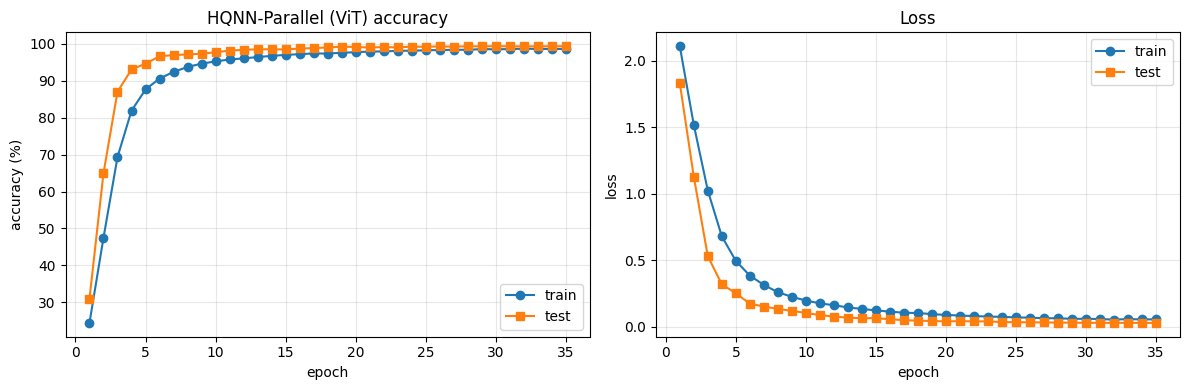

In [ ]:
# 10. Learning curves.
epochs = range(1, len(history["train_acc"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [a*100 for a in history["train_acc"]], "o-", label="train")
ax1.plot(epochs, [a*100 for a in history["test_acc"]],  "s-", label="test")
ax1.set_xlabel("epoch"); ax1.set_ylabel("accuracy (%)")
ax1.set_title("HQNN-Parallel (ViT) accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, history["train_loss"], "o-", label="train")
ax2.plot(epochs, history["test_loss"],  "s-", label="test")
ax2.set_xlabel("epoch"); ax2.set_ylabel("loss")
ax2.set_title("Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# 11. Download the trained weights.
# from google.colab import files
# files.download("classical_vit_mnist.pt")
